# 02 — Ingestion d'API & ajout d'une nouvelle source

**Objectif (data engineering).** Montrer la mécanique d'ingestion multi-sources
qui alimente le tableau de bord : agrégations OpenAlex, facettes HAL,
financements scanR, reconstruction d'abstract, et surtout **l'ajout simple
d'une nouvelle API** (ici Crossref) grâce à une interface de connecteur uniforme.

Données 100 % réelles, requêtées en direct.

In [1]:
import httpx
import pandas as pd
import matplotlib.pyplot as plt

from lib import set_seeds, OpenAlexClient, HalClient, ScanrClient, CONFIG
from lib.viz import new_axes, BRAND, ACCENT

set_seeds()
oa = OpenAlexClient()
hal = HalClient()

## 1. OpenAlex — agrégations exhaustives par `group_by`

L'agrégation `group_by` calcule un décompte sur **tout le corpus** sans
télécharger les notices. Piège traité : OpenAlex plafonne la taille du tableau
renvoyé à la valeur de `per-page` (d'où `per-page=200`).

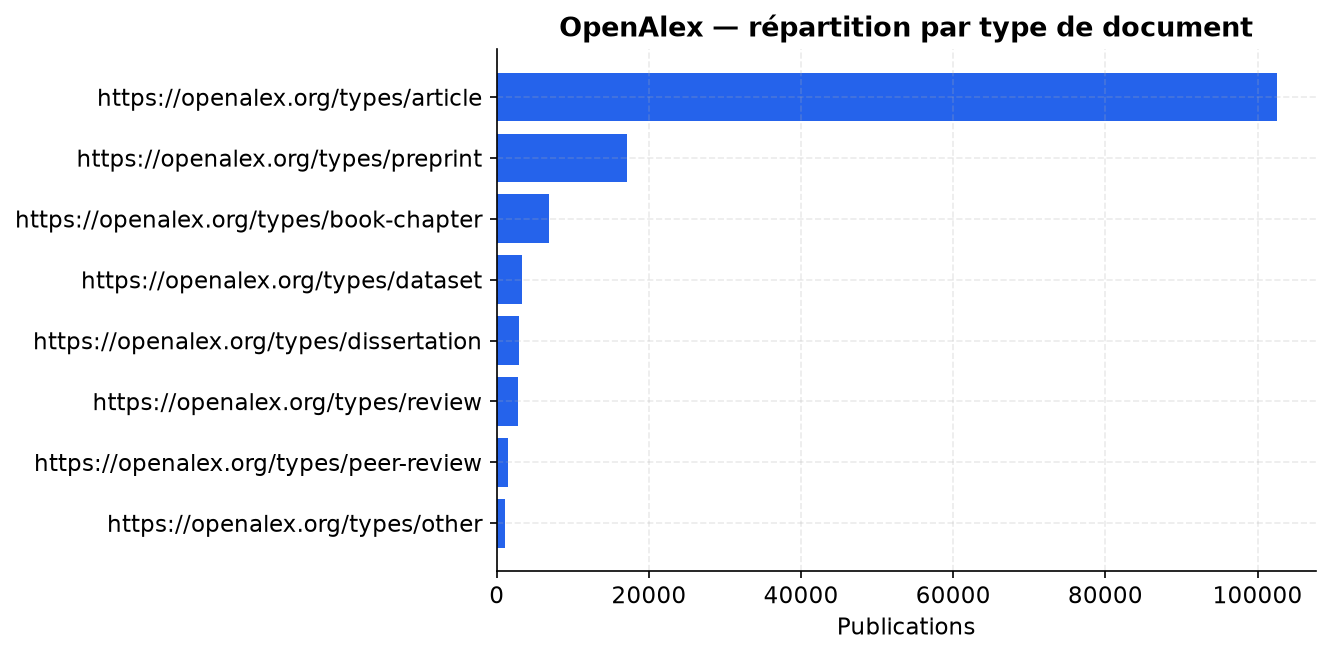

,type,count
0,https://openalex.org/types/article,102493
1,https://openalex.org/types/preprint,17061
2,https://openalex.org/types/book-chapter,6844
3,https://openalex.org/types/dataset,3274
4,https://openalex.org/types/dissertation,2975
5,https://openalex.org/types/review,2851
6,https://openalex.org/types/peer-review,1450
7,https://openalex.org/types/other,1087


In [2]:
oa_by_type = oa.group_by("type")
df_type = (
    pd.DataFrame(oa_by_type)[["key", "count"]]
    .rename(columns={"key": "type"})
    .sort_values("count", ascending=False)
    .head(8)
)
ax = new_axes("OpenAlex — répartition par type de document", xlabel="Publications")
ax.barh(df_type["type"], df_type["count"], color=BRAND)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
df_type

## 2. OpenAlex — série temporelle par agrégations répétées

La série annuelle s'obtient en répétant l'agrégation année par année (filtre
`publication_year`), illustrant la construction d'un *data mart* temporel.

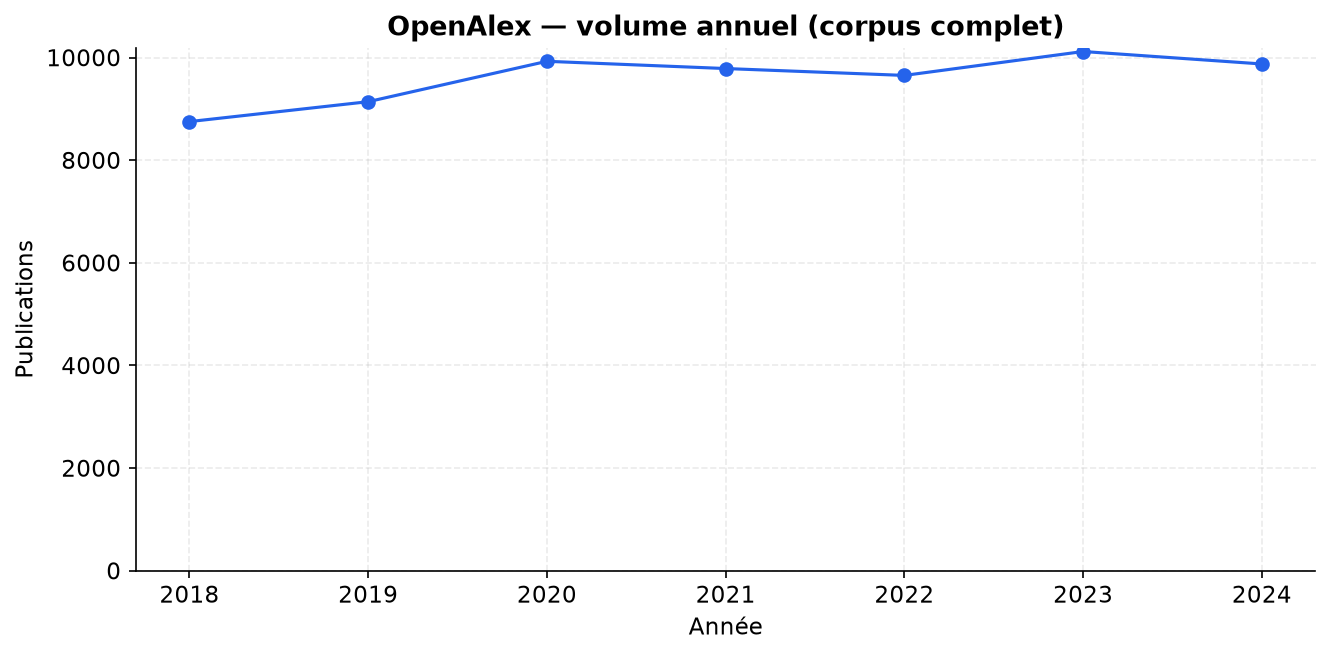

In [3]:
years = list(range(2018, 2025))
volume = []
for y in years:
    buckets = oa.group_by("publication_year", oa.institution_filter(publication_year=str(y)))
    volume.append(sum(b["count"] for b in buckets))
ax = new_axes("OpenAlex — volume annuel (corpus complet)", xlabel="Année", ylabel="Publications")
ax.plot(years, volume, marker="o", color=BRAND)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 3. HAL — facettes Solr

HAL expose une API de style Solr : les facettes donnent directement la
répartition par type de dépôt sur le périmètre UGA.

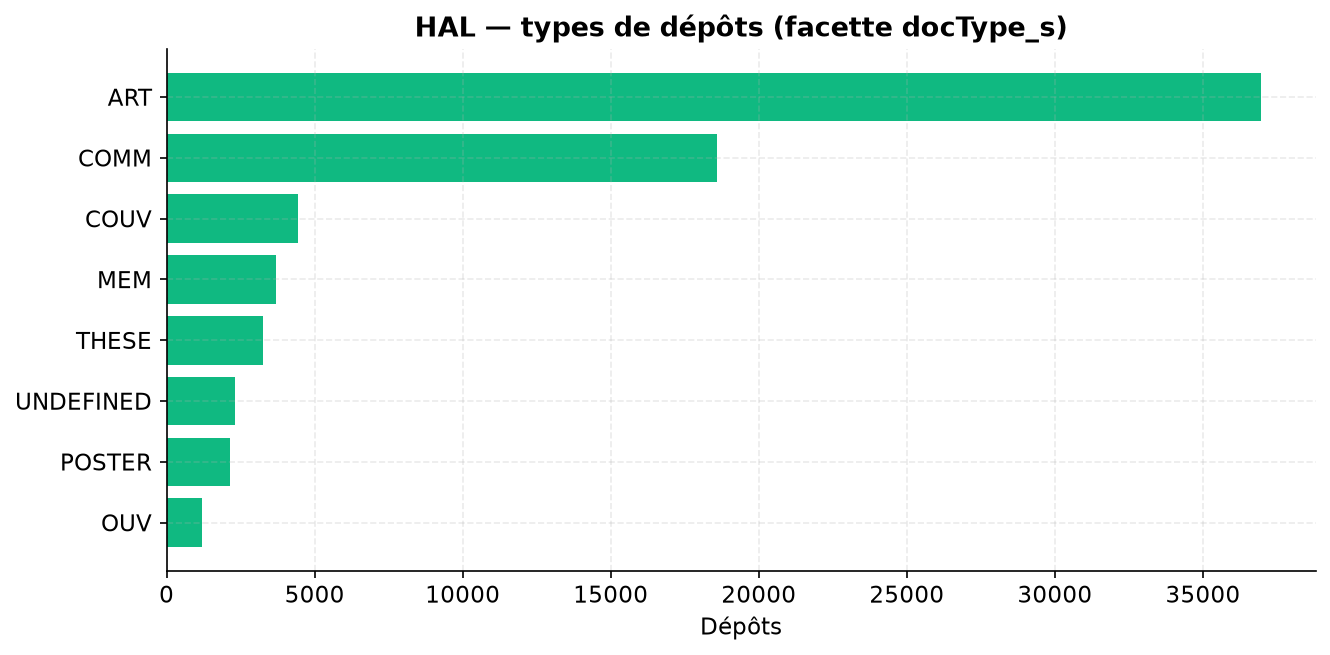

In [4]:
hal_types = hal.facet("docType_s")
df_hal = pd.Series(hal_types).sort_values(ascending=False).head(8)
ax = new_axes("HAL — types de dépôts (facette docType_s)", xlabel="Dépôts")
ax.barh(df_hal.index, df_hal.values, color=ACCENT)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Reconstruction d'abstract (index inversé OpenAlex)

OpenAlex ne fournit pas le résumé en texte mais un **index inversé**
(mot → positions). On le reconstruit pour l'analyse textuelle (notebook 04).

In [5]:
sample = next(
    oa.iter_works(
        oa.institution_filter(publication_year="2023"),
        "title,abstract_inverted_index",
        max_works=1,
    )
)
abstract = OpenAlexClient.reconstruct_abstract(sample.get("abstract_inverted_index"))
print("Titre   :", sample.get("title"))
print("Abstract:", (abstract[:400] + "…") if len(abstract) > 400 else abstract)

Titre   : Principles, Recent Developmentsand Perspectives in Boron NeutronCapture Therapy (BNCT)
Abstract: For decades, BNCT was seen as an attractive concept and an intellectual challenge with no prospect of widespread clinical application. This situation has changed fundamentally in just a few years with the progress in accelerator technology. Low-energy, high-intensity neutron sources can now be integrated into hospitals and are therefore directly available for patient treatment. A pioneer in this f…


## 5. scanR — financements de la recherche (MESR)

Troisième source : les contrats financés (ANR, PIA, H2020, Horizon Europe…),
filtrés sur les projets ayant un partenaire grenoblois.

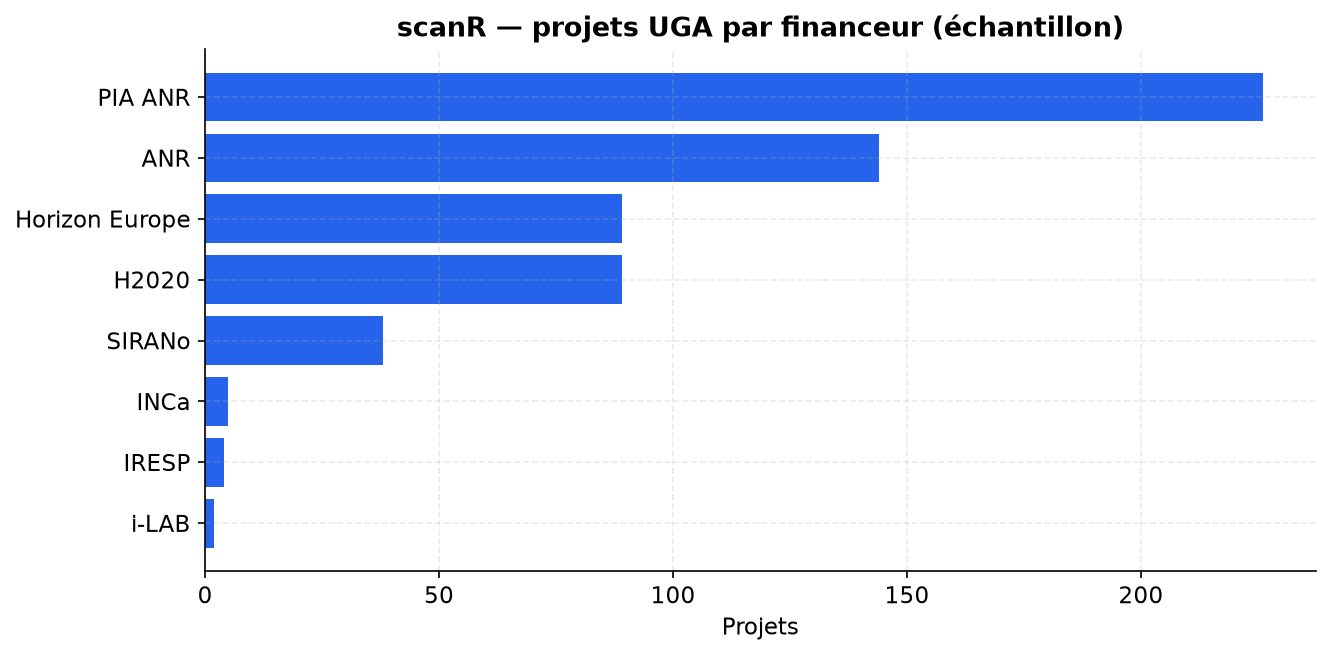

In [6]:
scanr = ScanrClient()
funders: dict[str, int] = {}
for rec in scanr.iter_uga(max_rows=600):
    funders[rec.get("type", "?")] = funders.get(rec.get("type", "?"), 0) + 1
df_fund = pd.Series(funders).sort_values(ascending=False).head(8)
ax = new_axes("scanR — projets UGA par financeur (échantillon)", xlabel="Projets")
ax.barh(df_fund.index, df_fund.values, color=BRAND)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Ajouter une nouvelle source en quelques lignes

L'architecture repose sur des connecteurs uniformes. Brancher une **nouvelle
API** (ici **Crossref**) ne demande qu'une petite fonction qui renvoie un
décompte comparable — sans toucher au reste du pipeline.

In [7]:
def crossref_count(affiliation: str) -> int:
    """Nombre de publications Crossref pour une affiliation (nouvelle source)."""
    res = httpx.get(
        "https://api.crossref.org/works",
        # `mailto` = pool poli Crossref (bonne pratique, comme pour OpenAlex).
        params={"query.affiliation": affiliation, "rows": 0, "mailto": CONFIG.mailto},
        timeout=30.0,
    )
    res.raise_for_status()
    return res.json()["message"]["total-results"]


# Total OpenAlex via `meta.count` (décompte exact du corpus, sans pagination).
oa_total = oa.count()

comparison = pd.DataFrame(
    {
        "source": ["OpenAlex", "HAL", "Crossref"],
        "publications": [
            oa_total,
            sum(hal.facet("docType_s").values()),
            crossref_count("Universite Grenoble Alpes"),
        ],
    }
)
comparison

,source,publications
0,OpenAlex,140692
1,HAL,77382
2,Crossref,96101


**Lecture.** Trois sources hétérogènes (REST agrégé, Solr, ODS) sont ingérées
via la même logique, et une quatrième (Crossref) se branche en une fonction.
C'est exactement le principe de l'interface `Connector` du pipeline TypeScript :
**ajouter une source = implémenter une interface**, sans réécrire l'aval.